In [1]:
from aeon.benchmarking.published_results import (
    load_classification_bake_off_2023_results,
)
from aeon.visualisation import plot_critical_difference
import polars as pl
import numpy as np
from aeon.datasets.tsc_datasets import univariate
from autotsc import utils
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
results_arr, datasets, classifiers = load_classification_bake_off_2023_results(
    num_resamples=30, as_array=True
)
results_arr.shape

(112, 34)

In [3]:
res_mine = pl.scan_parquet("s3://tsc-glue/performance-benchmarking/*.parquet").collect()
len(res_mine)

/tmp/ipykernel_1470535/2676074629.py:1: UserWarning: '(default_)region' not set; polars will try to get it from bucket

Set the region manually to silence this warning.
  res_mine = pl.scan_parquet("s3://tsc-glue/performance-benchmarking/*.parquet").collect()


35438

In [4]:
pivoted = res_mine.pivot(values="test_accuracy", index="dataset", on="model", aggregate_function='len')
numeric_cols = [c for c in pivoted.columns if c != "dataset"]
sum_row = pl.DataFrame([{"dataset": "all", **{c: pivoted[c].sum() for c in numeric_cols}}]).with_columns([
    pl.col(c).cast(pl.UInt32) for c in numeric_cols
])
result = pl.concat([pivoted, sum_row])
result

dataset,mr-hydra-contained-auto,mr-hydra-kbest-5000,loky-stacker-v6-soft-ridge,loky-stacker-v6,mr-hydra-kbest-auto,loky-stacker-v6-soft-et,mr-hydra-kbest-10000,loky-stacker-v6-soft-rf,mr-hydra-kbest-30000,loky-stacker-v7,loky-stacker-v5-soft-et,loky-stacker-v5-soft-ridge,loky-stacker-v5-soft-rf,loky-stacker-v5-r1,loky-stacker-v7-soft-filter-ridge
str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""SwedishLeaf""",30,30,30,30,30,30,30,30,30,27,4,3,4,10,0
"""BeetleFly""",30,30,30,30,30,30,30,30,30,27,4,8,4,2,0
"""Meat""",30,30,30,30,30,30,30,30,30,27,6,8,5,5,0
"""PhalangesOutlinesCorrect""",30,30,30,30,30,30,30,30,30,28,4,5,10,6,0
"""FaceFour""",30,30,30,30,30,30,30,30,30,26,5,3,5,7,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""SmoothSubspace""",30,30,30,30,30,30,30,30,30,26,7,4,3,7,0
"""ElectricDevices""",30,30,30,30,30,30,30,30,30,27,3,2,5,4,0
"""ProximalPhalanxOutlineAgeGroup""",30,30,30,30,30,30,30,30,30,27,6,3,6,9,0


In [5]:
mine_classifiers = res_mine['model'].unique().to_list()

In [6]:
df_performance = pl.DataFrame(results_arr, schema=classifiers).with_columns(pl.Series("dataset", datasets))
df_performance_mine = res_mine.pivot(values="test_accuracy", index="dataset", on="model", aggregate_function='mean')
df_performance_full = df_performance.join(other=df_performance_mine, on='dataset')

In [7]:
df_performance_full = df_performance_full#.drop(mine_classifiers)
len(df_performance_full)

112

In [8]:
df_performance_full = df_performance_full.drop([col for col in df_performance_full.columns if df_performance_full[col].null_count() > 0])

In [9]:
drop_models = ['ShapeDTW', 'EE', 'ResNet', 'CNN', 
               'CIF', 'BOSS', 'TSFresh', 'Arsenal', 
               'HC1', 'Hydra', '1NN-DTW', 'ROCKET', 
               'Mini-R', 'WEASEL-D', 'InceptionT', 'Signatures', 'RISE', 'DrCIF', 'TDE', 
               'loky-stacker-v5-soft-et',
               'loky-stacker-v5-soft-ridge',	
               'loky-stacker-v5-soft-rf',	
               'loky-stacker-v5-r1',
]

In [10]:
df_performance_full = df_performance_full.drop(drop_models)

In [11]:
df_performance_full.columns

['Catch22',
 'FreshPRINCE',
 'HC2',
 'Hydra-MR',
 'MrSQM',
 'Multi-R',
 'PF',
 'RDST',
 'RSF',
 'RSTSF',
 'STC',
 'TS-CHIEF',
 'TSF',
 'WEASEL',
 'cBOSS',
 'dataset',
 'mr-hydra-contained-auto',
 'mr-hydra-kbest-5000',
 'loky-stacker-v6-soft-ridge',
 'loky-stacker-v6',
 'mr-hydra-kbest-auto',
 'loky-stacker-v6-soft-et',
 'mr-hydra-kbest-10000',
 'loky-stacker-v6-soft-rf',
 'mr-hydra-kbest-30000',
 'loky-stacker-v7']

/home/petelin/AutoTSC/.venv/lib/python3.13/site-packages/aeon/visualisation/results/_critical_difference.py:217: UserWarning: Estimators mr-hydra-contained-auto and mr-hydra-kbest-auto have the same performanceon all datasets. This may cause problems when forming cliques.
  p_values = wilcoxon_test(ordered_scores, ordered_labels, lower_better)


(<Figure size 600x440 with 1 Axes>, <Axes: >)

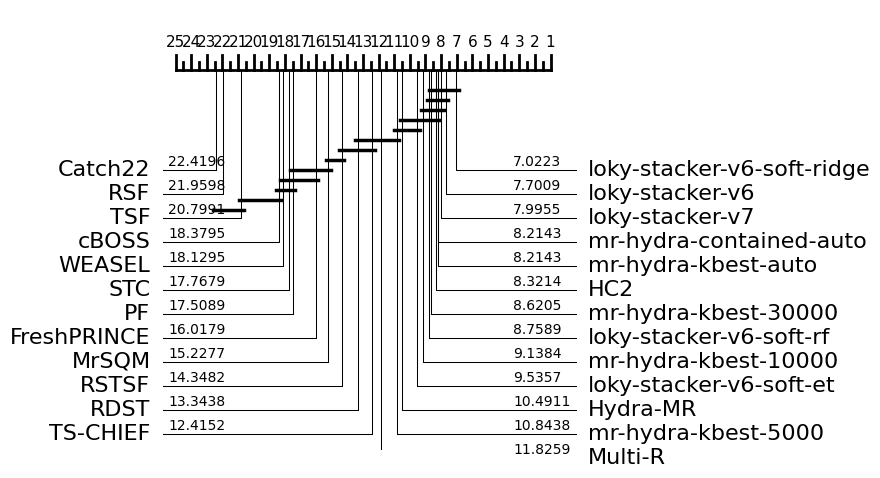

In [12]:
clsf = df_performance_full.select([c for c in df_performance_full.columns if c != "dataset"])
plot_critical_difference(clsf.to_numpy(), clsf.columns)

In [13]:
clsf

Catch22,FreshPRINCE,HC2,Hydra-MR,MrSQM,Multi-R,PF,RDST,RSF,RSTSF,STC,TS-CHIEF,TSF,WEASEL,cBOSS,mr-hydra-contained-auto,mr-hydra-kbest-5000,loky-stacker-v6-soft-ridge,loky-stacker-v6,mr-hydra-kbest-auto,loky-stacker-v6-soft-et,mr-hydra-kbest-10000,loky-stacker-v6-soft-rf,mr-hydra-kbest-30000,loky-stacker-v7
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.881227,0.948427,0.962613,0.97248,0.956693,0.97296,0.953067,0.963467,0.882827,0.951573,0.930507,0.96192,0.893547,0.960053,0.915573,0.979147,0.97136,0.973707,0.974507,0.979147,0.976107,0.978133,0.975307,0.979093,0.974163
0.851667,0.881667,0.911667,0.911667,0.963333,0.895,0.86,0.926667,0.875,0.885,0.951667,0.958333,0.823333,0.92,0.96,0.928333,0.921667,0.895,0.9,0.928333,0.89,0.926667,0.898333,0.918333,0.892593
0.941111,0.980556,0.988889,0.984444,0.976667,0.983333,0.987222,0.981667,0.968889,0.984444,0.980556,0.984444,0.981667,0.961111,0.974444,0.992222,0.992222,0.988889,0.984444,0.992222,0.988333,0.99,0.988333,0.990556,0.984568
0.792152,0.847708,0.843706,0.859402,0.816861,0.857964,0.829099,0.829099,0.817211,0.841414,0.833877,0.82533,0.811772,0.811305,0.780109,0.855089,0.842424,0.862626,0.860917,0.855089,0.856721,0.847086,0.857304,0.854662,0.861014
0.660606,0.830682,0.973864,0.903409,0.953409,0.897727,0.945455,0.990909,0.91553,0.928409,0.87197,0.999621,0.895833,0.958333,0.99697,0.919318,0.919318,0.960227,0.960606,0.919318,0.929545,0.916667,0.92803,0.910227,0.956294
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.689394,0.676407,0.678139,0.656926,0.645887,0.654762,0.658874,0.672078,0.687879,0.696753,0.660606,0.694372,0.660606,0.648701,0.678788,0.661472,0.707359,0.698052,0.678571,0.661472,0.658442,0.680303,0.665368,0.661039,0.677249
0.852222,0.971556,0.981333,0.984444,0.819111,0.979778,0.998,0.992222,0.978444,0.983111,0.946222,0.997333,0.986222,0.782889,0.415111,0.983778,0.984222,0.991778,0.994667,0.983778,0.994667,0.983778,0.995111,0.980222,0.994615
0.867281,0.908339,0.899036,0.902927,0.871223,0.900048,0.842442,0.896572,0.817987,0.879021,0.833325,0.865041,0.805187,0.888968,0.829421,0.907751,0.88548,0.907941,0.90932,0.907751,0.911192,0.899494,0.91197,0.907729,0.9085


(<Figure size 600x260 with 1 Axes>, <Axes: >)

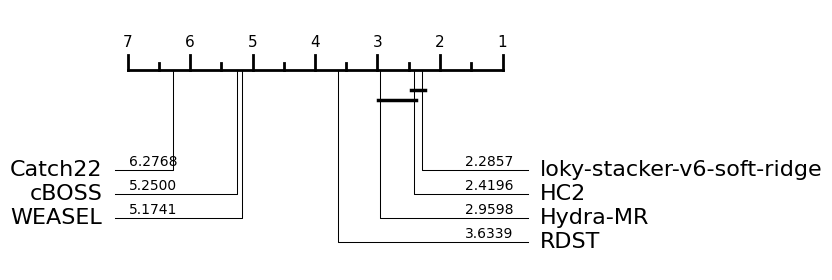

In [14]:
clsf = df_performance_full.select(['loky-stacker-v6-soft-ridge', 'HC2', 'Hydra-MR', 'cBOSS', 'Catch22', 'RDST', 'WEASEL'])
plot_critical_difference(clsf.to_numpy(), clsf.columns)

In [15]:
v = (df_performance_full['loky-stacker-v6-soft-ridge'] - df_performance_full['HC2']).to_numpy()
(v>0).sum(), (v<0).sum(), (v==0).sum()

(np.int64(61), np.int64(46), np.int64(5))

In [16]:
def dataset_stats():

    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append(
            {
                "dataset": dataset,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_classes": len(np.unique(y_train)),
                "series_length": X_train.shape[2],
            }
        )
    return pl.DataFrame(stats)


stats = dataset_stats()

df_performance_full.join(stats, on='dataset').sort('n_train')

Catch22,FreshPRINCE,HC2,Hydra-MR,MrSQM,Multi-R,PF,RDST,RSF,RSTSF,STC,TS-CHIEF,TSF,WEASEL,cBOSS,dataset,mr-hydra-contained-auto,mr-hydra-kbest-5000,loky-stacker-v6-soft-ridge,loky-stacker-v6,mr-hydra-kbest-auto,loky-stacker-v6-soft-et,mr-hydra-kbest-10000,loky-stacker-v6-soft-rf,mr-hydra-kbest-30000,loky-stacker-v7,n_train,n_test,n_classes,series_length
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
0.908279,0.916993,0.946841,0.950436,0.890741,0.952179,0.956754,0.944989,0.919935,0.937146,0.924619,0.945861,0.940632,0.894553,0.881046,"""DiatomSizeReduction""",0.949891,0.948366,0.952179,0.952179,0.949891,0.952179,0.951525,0.952179,0.954575,0.953595,16,306,4,345
0.986613,0.999866,0.999331,0.984739,0.857028,0.996252,1.0,0.965194,1.0,1.0,0.905087,1.0,1.0,1.0,0.998527,"""InsectEPGSmallTrain""",1.0,1.0,1.0,0.997189,1.0,1.0,1.0,0.999732,0.999465,0.997025,17,249,3,601
0.851667,0.881667,0.911667,0.911667,0.963333,0.895,0.86,0.926667,0.875,0.885,0.951667,0.958333,0.823333,0.92,0.96,"""BeetleFly""",0.928333,0.921667,0.895,0.9,0.928333,0.89,0.926667,0.898333,0.918333,0.892593,20,20,2,512
0.888333,0.923333,0.946667,0.91,0.958333,0.89,0.903333,0.913333,0.833333,0.963333,0.915,0.963333,0.821667,0.906667,0.981667,"""BirdChicken""",0.906667,0.908333,0.933333,0.923333,0.906667,0.948333,0.908333,0.941667,0.905,0.916,20,20,2,512
0.892323,0.972789,0.970068,0.965792,0.95345,0.966569,0.948019,0.968416,0.883479,0.975607,0.955102,0.961836,0.954227,0.939456,0.942857,"""Chinatown""",0.969485,0.970068,0.974733,0.970068,0.969485,0.972206,0.969388,0.971914,0.967055,0.969631,20,343,2,24
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.792152,0.847708,0.843706,0.859402,0.816861,0.857964,0.829099,0.829099,0.817211,0.841414,0.833877,0.82533,0.811772,0.811305,0.780109,"""PhalangesOutlinesCorrect""",0.855089,0.842424,0.862626,0.860917,0.855089,0.856721,0.847086,0.857304,0.854662,0.861014,1800,858,2,80
0.908636,1.0,0.953712,0.955354,0.95,0.954141,0.850025,0.949242,0.876515,0.977803,0.934242,0.947399,0.81846,0.960657,0.908939,"""FordA""",0.955884,0.956288,0.981288,0.983283,0.955884,0.985076,0.955707,0.985429,0.95548,0.983152,3601,1320,2,500
0.867778,0.9207,0.933868,0.931193,0.922798,0.929671,0.839383,0.928601,0.85786,0.922593,0.9193,0.919465,0.785267,0.928354,0.883086,"""FordB""",0.93107,0.929095,0.938601,0.93716,0.93107,0.93642,0.932922,0.936255,0.930905,0.935654,3636,810,2,500


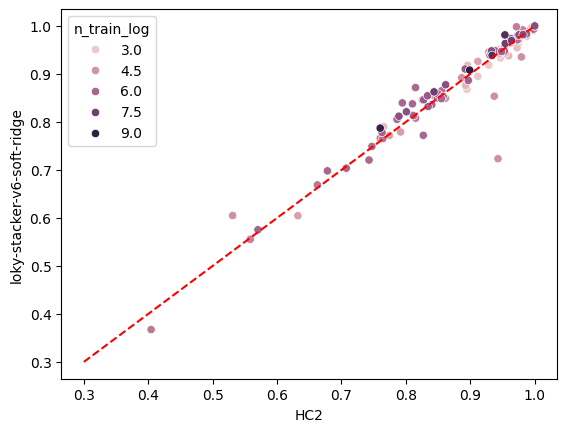

In [17]:
m1 = 'HC2'
m2 = 'loky-stacker-v6-soft-ridge'
data = df_performance_full.join(stats, on='dataset').with_columns(pl.col('n_train').log().alias('n_train_log')).sort('n_train')
sns.scatterplot(data=data.to_pandas(), x=m1, y=m2, hue='n_train_log')
#plt.scatter(clsf[m1], clsf[m2], alpha=0.7, edgecolors='b', s=5)
plt.xlabel(m1)
plt.ylabel(m2)
plt.plot([0.3, 1], [0.3, 1], 'r--')

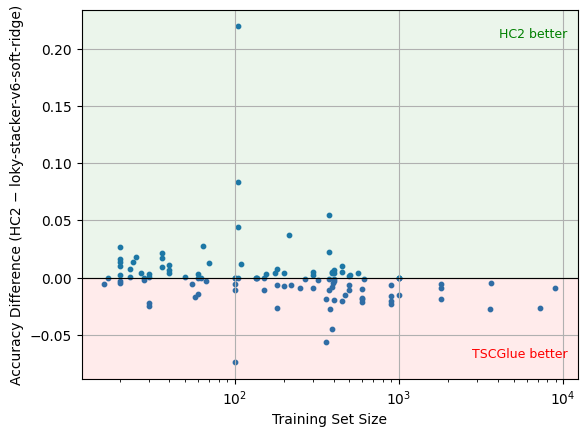

In [18]:
plt.scatter(data['n_train'], data[m1]-data[m2], s=10)
plt.xlabel('Training Set Size')
plt.ylabel(f'Accuracy Difference ({m1} − {m2})')
plt.xscale('log')
plt.grid()
plt.axhline(0, color='black', linewidth=0.8)
ylim = plt.gca().get_ylim()
plt.axhspan(0, ylim[1], alpha=0.08, color='green')
plt.axhspan(ylim[0], 0, alpha=0.08, color='red')
plt.text(0.98, 0.95, 'HC2 better', transform=plt.gca().transAxes, ha='right', va='top', fontsize=9, color='green')
plt.text(0.98, 0.05, 'TSCGlue better', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=9, color='red')
plt.ylim(ylim)

directory = "figures"
Path(directory).mkdir(parents=True, exist_ok=True)

plt.savefig(f"{directory}/train_size.pdf", bbox_inches='tight', pad_inches=0)

In [ ]:
m1 = 'Hydra-MR'
m2 = 'loky-stacker-v5-soft-ridge'
data = df_performance_full.join(stats, on='dataset').with_columns(pl.col('n_train').log().alias('n_train_log')).sort('n_train')
sns.scatterplot(data=data.to_pandas(), x=m1, y=m2, hue='n_train_log')
#plt.scatter(clsf[m1], clsf[m2], alpha=0.7, edgecolors='b', s=5)
plt.xlabel(m1)
plt.ylabel(m2)
plt.plot([0.3, 1], [0.3, 1], 'r--')

ValueError: Could not interpret value `loky-stacker-v5-soft-ridge` for `y`. An entry with this name does not appear in `data`.

: 

In [ ]:
plt.scatter(data['n_train'], data[m1]-data[m2], s=10)
plt.xlabel('Training Set Size')
plt.ylabel(f'Accuracy Difference ({m1} − {m2})')
plt.xscale('log')
plt.grid()
plt.axhline(0, color='black', linewidth=0.8)
ylim = plt.gca().get_ylim()
plt.axhspan(0, ylim[1], alpha=0.08, color='green')
plt.axhspan(ylim[0], 0, alpha=0.08, color='red')
plt.text(0.98, 0.95, 'HC2 better', transform=plt.gca().transAxes, ha='right', va='top', fontsize=9, color='green')
plt.text(0.98, 0.05, 'TSCGlue better', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=9, color='red')
plt.ylim(ylim)

In [ ]:
m1 = 'TS-CHIEF'
m2 = 'loky-stacker-v5-soft-ridge'
data = df_performance_full.join(stats, on='dataset').with_columns(pl.col('n_train').log().alias('n_train_log')).sort('n_train')
sns.scatterplot(data=data.to_pandas(), x=m1, y=m2, hue='n_train_log')
#plt.scatter(clsf[m1], clsf[m2], alpha=0.7, edgecolors='b', s=5)
plt.xlabel(m1)
plt.ylabel(m2)
plt.plot([0.3, 1], [0.3, 1], 'r--')

In [ ]:
plt.scatter(data['n_train'], data[m1]-data[m2], s=10)
plt.xlabel('Training Set Size')
plt.ylabel(f'Accuracy Difference ({m1} − {m2})')
plt.xscale('log')
plt.grid()
plt.axhline(0, color='black', linewidth=0.8)
ylim = plt.gca().get_ylim()
plt.axhspan(0, ylim[1], alpha=0.08, color='green')
plt.axhspan(ylim[0], 0, alpha=0.08, color='red')
plt.text(0.98, 0.95, 'HC2 better', transform=plt.gca().transAxes, ha='right', va='top', fontsize=9, color='green')
plt.text(0.98, 0.05, 'TSCGlue better', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=9, color='red')
plt.ylim(ylim)